In [21]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

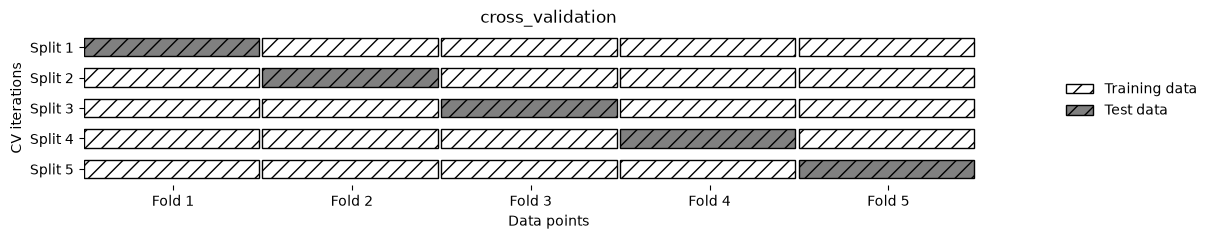

In [22]:
#K分割交差検証
mglearn.plots.plot_cross_validation()

In [23]:
#scikit-learnでの交差検証

from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

#デフォルトの分割数は5である。交差検証の結果は、各分割における精度の配列として返される。
scores = cross_val_score(logreg,iris.data,iris.target,cv=5)

print("Cross-validation scores:{}".format(scores))

Cross-validation scores:[0.96666667 1.         0.93333333 0.96666667 1.        ]


In [24]:
#交差検証の精度をまとめるには、一般に平均値を用いる
print("Average cross-validation score:{:.2f}".format(scores.mean()))

Average cross-validation score:0.97


In [25]:
#単純なK分割交差検証では、各分割におけるクラスの割合が全体のクラスの割合と同じになるとは限らない。
#クラス分類気の場合、層化K分割交差検証を用いるのが一般的である。
# 層化K分割交差検証では、各分割におけるクラスの割合が全体のクラスの割合と同じになるように分割される。

print("Iris labels:\n{}".format(iris.target))

Iris labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


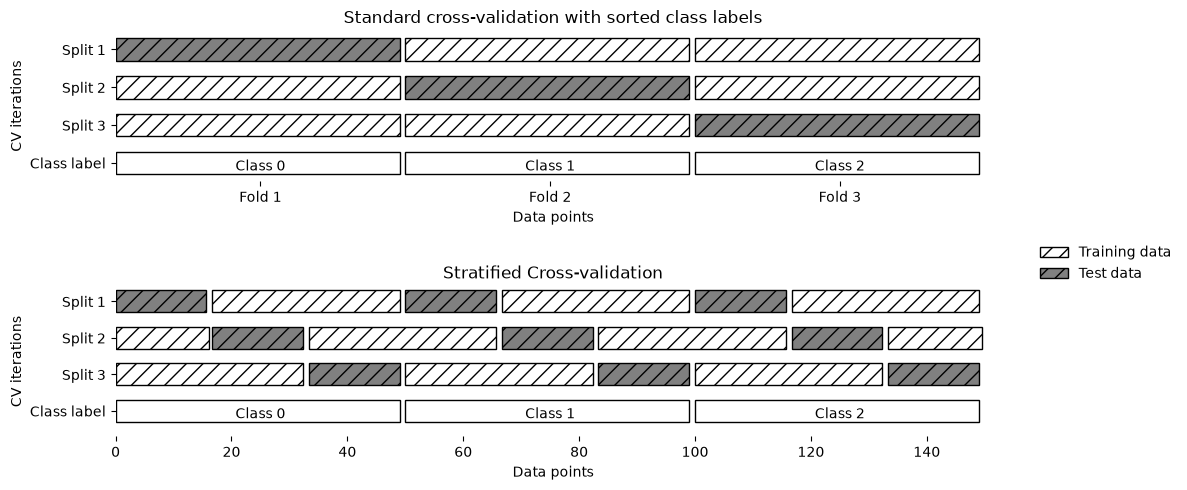

In [26]:
mglearn.plots.plot_stratified_cross_validation()

In [27]:
#交差検証のより詳細な制御のために、cvパラメータにKFoldクラスのインスタンスを渡すことができる。

from sklearn.model_selection import KFold
kfold = KFold(n_splits=5)

print("Cross-vaidation scores:\n{}".format(
    cross_val_score(logreg,iris.data,iris.target,cv=kfold)
))

Cross-vaidation scores:
[1.         1.         0.86666667 0.93333333 0.83333333]


In [28]:
#三分割の層化されていない交差検証をirisデータっとに使うとひどいことになることを確認してみる
#そのため、層化k分割交差検証を使うためにStratifiedKFoldクラスを使う

kfold = KFold(n_splits=3)
print("Cross-validation scores:\n{}".format(
    cross_val_score(logreg,iris.data,iris.target,cv=kfold)
))

Cross-validation scores:
[0. 0. 0.]


In [29]:
#分割前にデータをシャッフルしてみる
kfold = KFold(
    n_splits=3,
    shuffle=True,
    random_state=0
)

print("Cross-validation scores:\n{}".format(
    cross_val_score(logreg,iris.data,iris.target,cv=kfold)
))

Cross-validation scores:
[0.98 0.96 0.96]


In [30]:
# 一つ抜き交差検証（Leave-One-Out Cross Validation）
# データを1つだけテストデータにし、残りすべてを訓練データとして評価する
# これを全データが1回ずつテストデータになるまで繰り返す
# データ数をnとすると、n回モデルを学習する（k分割交差検証のk=nに相当）
# 訓練データを最大限利用できるが、データ数が多いと計算量が大きくなる

from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(
    logreg, iris.data, iris.target, cv=loo
)
print("Number of cv iterations:`{}".format(len(scores)))
print("Mean accuracy:{:.2f}".format(scores.mean()))


Number of cv iterations:`150
Mean accuracy:0.97


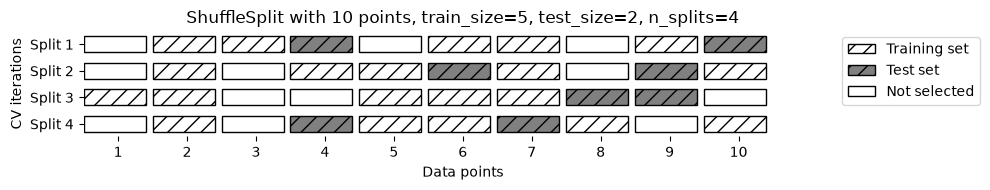

In [31]:
# シャッフル分割交差検証（ShuffleSplit）
# データをランダムにシャッフルし、指定した割合で訓練データとテストデータに分割する
# このランダムな分割を指定した回数だけ繰り返してモデルを評価する
# 通常のk分割と異なり、同じデータが複数回テストデータになったり、一度もならないこともある
#層化バージョンもある

#１０点に対するtrain_size=5,test_size=2のシャッフル分割交差検証を5回繰り返す例
mglearn.plots.plot_shuffle_split()

In [32]:
#データセット50パーセントを訓練セットに、50パーセントをテストセットにして１０回分割を繰り返してみる
from sklearn.model_selection import ShuffleSplit
shuffle_split = ShuffleSplit(
    test_size=0.5,
    train_size=0.5,
    n_splits=10
)

scores = cross_val_score(
    logreg,
    iris.data,
    iris.target,
    cv=shuffle_split  
)

print("Cross-validation scores:\n{}".format(scores))

Cross-validation scores:
[0.94666667 0.97333333 0.97333333 0.96       0.94666667 0.97333333
 0.97333333 0.98666667 0.93333333 0.96      ]


In [33]:
# グループ付き交差検証（GroupKFold）
# 同じグループに属するデータが、訓練データとテストデータに分かれないように交差検証を行う
# 同一人物から複数のデータを取得した場合など、互いに関連するデータがあるときに使用する
# データリークを防ぎ、未知のグループに対する性能を評価できる

from sklearn.model_selection import GroupKFold
from sklearn.datasets import make_blobs

#合成データセットを生成
x,y  = make_blobs(n_samples=12,random_state=0)

#最初の3サンプルが同じグループに、次の４つが同じグループになるようにする
groups = [0,0,0,1,1,1,1,2,2,3,3,3]
scores = cross_val_score(
    logreg,
    x,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=3)
)

print("Cross-validation scores:\n{}".format(scores))


Cross-validation scores:
[0.75       0.6        0.66666667]


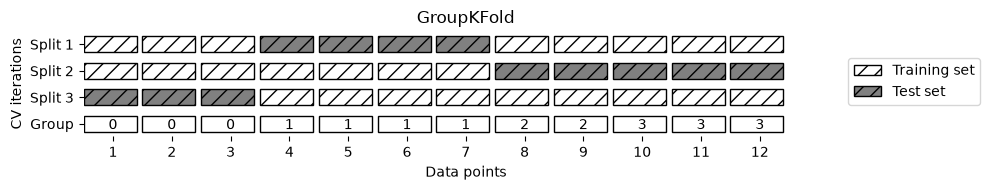

In [34]:
#個々のグループは、完全に訓練セットに入ってるか、完全にテストセットに入っているかのどちらかになる
mglearn.plots.plot_group_kfold()